In [9]:
import requests
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import matplotlib.colors as mcolors
import astropy.units as u
import pandas as pd
import sympy as sp

from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.cosmology import FlatLambdaCDM
from pysr import PySRRegressor
from scipy.stats import binned_statistic_dd
from sklearn.metrics import mean_squared_error, median_absolute_error
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture
from scipy.stats import norm


Get function for downloads and API reading

In [10]:
# define function to get data from api and downloads
baseURL = 'http://www.tng-project.org/api/'
headers = {"api-key": "96ec8ab7a20d9b1666d6f0a5a4a8e0b9"}

def get(path, local_filename=None, params=None, max_retries=5):
    if local_filename and os.path.exists(local_filename):
        print(f"File {local_filename} already exists. Skipping network request.")
        return local_filename

    # ensure we use full URL pathways if just the API endpoint stub was provided
    url = path if path.startswith('http') else baseURL + path

    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, headers=headers, stream=True)
            r.raise_for_status()

            if 'application/json' in r.headers.get('content-type', ''):
                return r.json()

            if not local_filename:
                if 'content-disposition' in r.headers:
                    local_filename = r.headers['content-disposition'].split("filename=")[1]
                else:
                    local_filename = url.split('/')[-1] if url.split('/')[-1] else 'downloaded_tng_file'

            if os.path.exists(local_filename):
                print(f"File {local_filename} derived from header already exists. Skipping save.")
                return local_filename

            # disk stream download routine with live visual readout
            total_size = int(r.headers.get('content-length', 0))
            block_size = 1024 * 1024  # 1 Megabyte chunks
            
            if total_size > 0:
                print(f"Downloading {local_filename} ({total_size / (1024**3):.2f} GB)...")
            else:
                print(f"Downloading {local_filename} (Unknown total file size)...")

            with open(local_filename, 'wb') as f:
                dl = 0
                start_time = time.time()
                for chunk in r.iter_content(chunk_size=block_size):
                    if chunk:
                        f.write(chunk)
                        dl += len(chunk)
                        
                        # status bar tracker
                        if total_size > 0:
                            done = int(50 * dl / total_size)
                            percent = (dl / total_size) * 100
                            elapsed = time.time() - start_time
                            speed = (dl / elapsed) / (1024**2) if elapsed > 0 else 0
                            print(f"\r[{'=' * done}{' ' * (50-done)}] {percent:.1f}% ({speed:.1f} MB/s)", end="")
                        else:
                            print(f"\rDownloaded: {dl / (1024**2):.1f} MB...", end="")
            print("\nDownload Complete!")
            return local_filename

        except requests.exceptions.HTTPError as e:
            # check for standard server-side rate limits or transient auth failures
            if r.status_code == 403 and attempt < max_retries - 1:
                wait_time = 2 ** attempt 
                print(f"\nAttempt {attempt+1} hit 403. Retrying in {wait_time}s...")
                time.sleep(wait_time)
                continue
            else:
                raise e

Extract and Prepare Data

In [11]:
# load data from files
snap = get("http://www.tng-project.org/api/TNG300-1/snapshots/")
tree_data = {'subhalos': {}}
with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG300_1_data.hdf5","r") as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        tree_data['subhalos'][key] = subhalos_grp[key][()]

with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG-Cluster_data.hdf5",'r') as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        new_data = subhalos_grp[key][()]
        existing_data = tree_data['subhalos'][key]
        tree_data['subhalos'][key] = np.concatenate((existing_data, new_data), axis=0)


In [12]:
# calculating lookback time

# this defines the constants we use in flat lambda CDM
cosmology = FlatLambdaCDM(H0=67.74, Om0=0.3089, Ob0=0.0486)

lookback_infall3 = cosmology.lookback_time(tree_data['subhalos']['infall_z3']).value
lookback_infall1 = cosmology.lookback_time(tree_data['subhalos']['infall_z1']).value
lookback_sub = cosmology.lookback_time(tree_data['subhalos']['z']).value

tree_data['subhalos']['lookback_time3'] = lookback_infall3 - lookback_sub

tree_data['subhalos']['lookback_time1'] = lookback_infall1 - lookback_sub


c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:496: RuntimeWarning: invalid value encountered in divide
  np.emath.sqrt((1 / self.Om0 - 1 + 0j) / (aszarr(z) + 1.0) ** 3)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:120: RuntimeWarning: invalid value encountered in less
  if any(isreal(x) & (x < 0)):
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:238: RuntimeWarning: invalid value encountered in sqrt
  return nx.sqrt(x)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:495: RuntimeWarning: invalid value encountered in arcsinh
  arg = np.arcsinh(


In [13]:
# recalculate 3d radius to filter out for 1 r200
tree_data['subhalos']['norm_r_3d'] = np.sqrt((tree_data['subhalos']['norm_r_xy']**2 + tree_data['subhalos']['norm_r_xz']**2 
                                              + tree_data['subhalos']['norm_r_yz']**2) / 2)

In [14]:
# store data in separate dicts for redshifts
r_axis = {}
v_axis = {}
infall_axis3 = {}
infall_axis1 = {}
stel = {}
vir = {}
log10stel = {}
log10vir = {}
steps = {}
z_inf = {}
infall_axis1_clean = {}
r_axis_clean = {}
v_axis_clean = {}
m_axis_clean = {}
mh_axis_clean = {}

snapshots = [99, 84, 78, 67, 59, 50]
for snapshot in snapshots:
    snapRmask = (tree_data['subhalos']['snap'] == snapshot) & (tree_data['subhalos']['norm_r_3d'] <= 1.0)
    r_axis[snapshot] = []
    v_axis[snapshot] = []
    infall_axis3[snapshot] = []
    infall_axis1[snapshot] = []
    stel[snapshot] = []
    vir[snapshot] = []
    log10stel[snapshot] = []
    log10vir[snapshot] = []
    steps[snapshot] = []
    z_inf[snapshot] = []

    r_axis[snapshot].append(tree_data['subhalos']['norm_r_xy'][snapRmask])
    r_axis[snapshot].append(tree_data['subhalos']['norm_r_xz'][snapRmask])
    r_axis[snapshot].append(tree_data['subhalos']['norm_r_yz'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_z'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_y'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_x'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    r_axis[snapshot] = np.concatenate(r_axis[snapshot])
    v_axis[snapshot] = np.concatenate(v_axis[snapshot])
    infall_axis3[snapshot] = np.concatenate(infall_axis3[snapshot])
    infall_axis1[snapshot] = np.concatenate(infall_axis1[snapshot])
    log10stel[snapshot] = np.log10(np.concatenate(stel[snapshot]))
    log10vir[snapshot] = np.log10(np.concatenate(vir[snapshot]))
    steps[snapshot] = np.concatenate(steps[snapshot])
    z_inf[snapshot] = np.concatenate(z_inf[snapshot])

    # filter nans
    valid = ~np.isnan(infall_axis1[snapshot])
    infall_axis1_clean[snapshot] = infall_axis1[snapshot][valid]
    r_axis_clean[snapshot] = r_axis[snapshot][valid]
    v_axis_clean[snapshot] = v_axis[snapshot][valid]
    m_axis_clean[snapshot] = log10stel[snapshot][valid]
    mh_axis_clean[snapshot] = log10vir[snapshot][valid]

Also collecting data separately

In [15]:
# all code for storing separate sims in this cell
tng300_data = {'subhalos': {}}
tngCluster_data = {'subhalos': {}}
with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG300_1_data.hdf5","r") as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        tng300_data['subhalos'][key] = subhalos_grp[key][()]

with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG-Cluster_data.hdf5",'r') as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        tngCluster_data['subhalos'][key] = subhalos_grp[key][()]
lookback_infall3 = cosmology.lookback_time(tng300_data['subhalos']['infall_z3']).value
lookback_infall1 = cosmology.lookback_time(tng300_data['subhalos']['infall_z1']).value
lookback_sub = cosmology.lookback_time(tng300_data['subhalos']['z']).value

tng300_data['subhalos']['lookback_time3'] = lookback_infall3 - lookback_sub
tng300_data['subhalos']['lookback_time1'] = lookback_infall1 - lookback_sub

lookback_infall3 = cosmology.lookback_time(tngCluster_data['subhalos']['infall_z3']).value
lookback_infall1 = cosmology.lookback_time(tngCluster_data['subhalos']['infall_z1']).value
lookback_sub = cosmology.lookback_time(tngCluster_data['subhalos']['z']).value

tngCluster_data['subhalos']['lookback_time3'] = lookback_infall3 - lookback_sub
tngCluster_data['subhalos']['lookback_time1'] = lookback_infall1 - lookback_sub
# recalculate 3d radius to filter out for 1 r200
tng300_data['subhalos']['norm_r_3d'] = np.sqrt((tng300_data['subhalos']['norm_r_xy']**2 + tng300_data['subhalos']['norm_r_xz']**2 
                                              + tng300_data['subhalos']['norm_r_yz']**2) / 2)

tngCluster_data['subhalos']['norm_r_3d'] = np.sqrt((tngCluster_data['subhalos']['norm_r_xy']**2 + tngCluster_data['subhalos']['norm_r_xz']**2 
                                              + tngCluster_data['subhalos']['norm_r_yz']**2) / 2)
# store data in separate dicts for redshifts
r = {'tng300': {}, 'cluster': {}}
v = {'tng300': {}, 'cluster': {}}
T_inf3 = {'tng300': {}, 'cluster': {}}
T_inf1 = {'tng300': {}, 'cluster': {}}
ms = {'tng300': {}, 'cluster': {}}
mh = {'tng300': {}, 'cluster': {}}
logms = {'tng300': {}, 'cluster': {}}
logmh = {'tng300': {}, 'cluster': {}}
steps = {'tng300': {}, 'cluster': {}}
z_inf = {'tng300': {}, 'cluster': {}}
T_inf1_clean = {'tng300': {}, 'cluster': {}}
r_clean = {'tng300': {}, 'cluster': {}}
v_clean = {'tng300': {}, 'cluster': {}}
logms_clean = {'tng300': {}, 'cluster': {}}
logmh_clean = {'tng300': {}, 'cluster': {}}

snapshots = [99, 84, 78, 67, 59, 50]
redshifts = [2.22044604925031e-16, 0.19728418237601, 0.297717684517447, 0.503047523244883, 0.700106353718523, 0.99729422578194]
sims = [tng300_data, tngCluster_data]

for i, key in enumerate(r.keys()):
    for snapshot in snapshots:
        snapRmask = (sims[i]['subhalos']['snap'] == snapshot) & (sims[i]['subhalos']['norm_r_3d'] <= 1.0)
        r[key][snapshot] = []
        v[key][snapshot] = []
        T_inf3[key][snapshot] = []
        T_inf1[key][snapshot] = []
        ms[key][snapshot] = []
        mh[key][snapshot] = []
        logms[key][snapshot] = []
        logmh[key][snapshot] = []
        steps[key][snapshot] = []
        z_inf[key][snapshot] = []

        r[key][snapshot].append(sims[i]['subhalos']['norm_r_xy'][snapRmask])
        r[key][snapshot].append(sims[i]['subhalos']['norm_r_xz'][snapRmask])
        r[key][snapshot].append(sims[i]['subhalos']['norm_r_yz'][snapRmask])
        v[key][snapshot].append(sims[i]['subhalos']['norm_v_z'][snapRmask])
        v[key][snapshot].append(sims[i]['subhalos']['norm_v_y'][snapRmask])
        v[key][snapshot].append(sims[i]['subhalos']['norm_v_x'][snapRmask])
        T_inf3[key][snapshot].append(sims[i]['subhalos']['lookback_time3'][snapRmask])
        T_inf3[key][snapshot].append(sims[i]['subhalos']['lookback_time3'][snapRmask])
        T_inf3[key][snapshot].append(sims[i]['subhalos']['lookback_time3'][snapRmask])
        T_inf1[key][snapshot].append(sims[i]['subhalos']['lookback_time1'][snapRmask])
        T_inf1[key][snapshot].append(sims[i]['subhalos']['lookback_time1'][snapRmask])
        T_inf1[key][snapshot].append(sims[i]['subhalos']['lookback_time1'][snapRmask])
        ms[key][snapshot].append(sims[i]['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
        ms[key][snapshot].append(sims[i]['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
        ms[key][snapshot].append(sims[i]['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
        mh[key][snapshot].append(sims[i]['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
        mh[key][snapshot].append(sims[i]['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
        mh[key][snapshot].append(sims[i]['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
        steps[key][snapshot].append(sims[i]['subhalos']['step_counts3'][snapRmask])
        steps[key][snapshot].append(sims[i]['subhalos']['step_counts3'][snapRmask])
        steps[key][snapshot].append(sims[i]['subhalos']['step_counts3'][snapRmask])
        z_inf[key][snapshot].append(sims[i]['subhalos']['infall_z3'][snapRmask])
        z_inf[key][snapshot].append(sims[i]['subhalos']['infall_z3'][snapRmask])
        z_inf[key][snapshot].append(sims[i]['subhalos']['infall_z3'][snapRmask])
        r[key][snapshot] = np.concatenate(r[key][snapshot])
        v[key][snapshot] = np.concatenate(v[key][snapshot])
        T_inf3[key][snapshot] = np.concatenate(T_inf3[key][snapshot])
        T_inf1[key][snapshot] = np.concatenate(T_inf1[key][snapshot])
        logms[key][snapshot] = np.log10(np.concatenate(ms[key][snapshot]))
        logmh[key][snapshot] = np.log10(np.concatenate(mh[key][snapshot]))
        steps[key][snapshot] = np.concatenate(steps[key][snapshot])
        z_inf[key][snapshot] = np.concatenate(z_inf[key][snapshot])

        # filter nans
        valid = ~np.isnan(T_inf1[key][snapshot])
        T_inf1_clean[key][snapshot] = T_inf1[key][snapshot][valid]
        r_clean[key][snapshot] = r[key][snapshot][valid]
        v_clean[key][snapshot] = v[key][snapshot][valid]
        logms_clean[key][snapshot] = logms[key][snapshot][valid]
        logmh_clean[key][snapshot] = logmh[key][snapshot][valid]

Binning the data (r<=1 only)

In [16]:
# ALL BINNING CODE
X_binned = {}
y_mean = {}
y_q1 = {}
y_med = {}
y_q3 = {}

for snapshot in snapshots:
    # prepare all raw inputs as a matrix with columns of each input
    X_clean = np.column_stack((r_axis_clean[snapshot], np.abs(v_axis_clean[snapshot]), m_axis_clean[snapshot], mh_axis_clean[snapshot]))
    y_clean = infall_axis1_clean[snapshot]

    # create percentile bins

    r_edges = np.percentile(X_clean[:,0], np.linspace(0, 100, 9))
    v_edges = np.percentile(X_clean[:,1], np.linspace(0, 100, 9))
    m_edges = np.percentile(X_clean[:,2], np.linspace(0, 100, 5))
    vir_edges = np.percentile(X_clean[:,3], np.linspace(0, 100, 5))

    quartile_bins = [r_edges, v_edges, m_edges, vir_edges]
    # sort data into bins

    # compute num of galaxies in each bin
    counts, _, _ = binned_statistic_dd(
        X_clean, values=None, statistic='count', bins=quartile_bins
    )

    # mask for only filled bins
    filled = np.where(counts > 0)
    Ngal_per = counts[filled]
    weights = np.log10(Ngal_per + 10)

    # extract mean features for grid size
    binned = []
    for i in range(X_clean.shape[1]):
        means, _, _ = binned_statistic_dd(X_clean, values=X_clean[:,i], statistic='mean', bins=quartile_bins)
        binned.append(means[filled])
    X_binned[snapshot] = np.column_stack(binned)

    mean_y, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic='mean', bins=quartile_bins)
    y_mean[snapshot] = mean_y[filled]

    q1_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 25), bins=quartile_bins)
    y_q1[snapshot] = q1_y_grid[filled]

    q2_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 50), bins=quartile_bins)
    y_med[snapshot] = q2_y_grid[filled]

    q3_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 75), bins=quartile_bins)
    y_q3[snapshot] = q3_y_grid[filled]

    print(f"Num of binned data points for PySR: {len(y_mean[snapshot])}")
    # mask for valid entries in bins
    mean_mask = ~np.isnan(y_mean[snapshot]) & (y_mean[snapshot] > 0)
    q1_mask = ~np.isnan(y_q1[snapshot]) & (y_q1[snapshot] > 0)
    med_mask = ~np.isnan(y_med[snapshot]) & (y_med[snapshot] > 0)
    q3_mask = ~np.isnan(y_q3[snapshot]) & (y_q3[snapshot] > 0)

    y_mean[snapshot] = y_mean[snapshot][mean_mask]
    y_q1[snapshot] = y_q1[snapshot][q1_mask]
    y_med[snapshot] = y_med[snapshot][med_mask]
    y_q3[snapshot] = y_q3[snapshot][q3_mask]

    # use if want to fit in log M* or log 10^10 M*
    # X_binned[snapshot][:,2] = X_binned[snapshot][:,2]-10
    # X_binned[snapshot][:,3] = X_binned[snapshot][:,3]-10

Num of binned data points for PySR: 1024
Num of binned data points for PySR: 1024
Num of binned data points for PySR: 1024
Num of binned data points for PySR: 1024
Num of binned data points for PySR: 1024
Num of binned data points for PySR: 1024


Coefficient Refit

In [17]:
def eqn1noMFit(Xvect, addR): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]

    return np.maximum(0,-v + (addR - r)**2)

def eqn2noMFit(Xvect, numer, addR): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]

    return np.maximum(0,-v + numer/(r + addR))

def eqn3Fit(Xvect, addM, addC): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]

    return np.maximum(0,-v - np.sqrt(r*((logms-10) + addM)) + addC)

def eqn3_2Fit(Xvect, coRoot, addC): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    return np.maximum(0,-v + coRoot*np.sqrt(logms*r) + addC)

def testz78Fit(Xvect, A, B, C): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    return np.maximum(0, A*v + (B*np.sqrt(logms*r) + C)**2)
    # return np.maximum(0,(A*v**2 + B*np.sqrt(logms*r) + C)**2)

In [19]:
poptEqn1 = {}
pcovEqn1 = {}
poptEqn2 = {}
pcovEqn2 = {}
poptEqn3 = {}
pcovEqn3 = {}
poptEqn3_2 = {}
pcovEqn3_2 = {}
popt78 = {}
pcov78 = {}
popt78_300 = {}
pcov78_300 = {}
popt78_Cluster = {}
pcov78_Cluster = {}

for snapshot in snapshots:
    print(f"| For snapshot: {snapshot} |")
    #fit on the total sample
    RvMhMs = np.array([r_axis_clean[snapshot],np.abs(v_axis_clean[snapshot]),m_axis_clean[snapshot]])
    params300 = np.array([r_clean['tng300'][snapshot],np.abs(v_clean['tng300'][snapshot]),logms_clean['tng300'][snapshot]])
    paramsCluster = np.array([r_clean['cluster'][snapshot],np.abs(v_clean['cluster'][snapshot]),logms_clean['cluster'][snapshot]])

    poptEqn1[snapshot], pcovEqn1[snapshot] = curve_fit(eqn1noMFit, (RvMhMs), infall_axis1_clean[snapshot], p0 = [2.589], nan_policy='omit')
    # prints values of each fitted coefficient
    print(f"Eqn1: {poptEqn1[snapshot]}")

    poptEqn2[snapshot], pcovEqn2[snapshot] = curve_fit(eqn2noMFit, (RvMhMs), infall_axis1_clean[snapshot], p0 = [3.757, 0.448], nan_policy='omit')
    print(f"Eqn2: {poptEqn2[snapshot]}")

    poptEqn3[snapshot], pcovEqn3[snapshot] = curve_fit(eqn3Fit, (RvMhMs), infall_axis1_clean[snapshot], p0 = [47.702, 8.937], nan_policy='omit')
    print(f"Eqn3: {poptEqn3[snapshot]}")

    poptEqn3_2[snapshot], pcovEqn3_2[snapshot] = curve_fit(eqn3_2Fit, (RvMhMs), infall_axis1_clean[snapshot], p0 = [-2.2, 8.945], nan_policy='omit')
    print(f"Eqn3_2: {poptEqn3_2[snapshot]}")

    popt78[snapshot], pcov78[snapshot] = curve_fit(testz78Fit, (RvMhMs), infall_axis1_clean[snapshot], p0 = [-0.617, 0.406, -2.569], nan_policy='omit')
    print(f"Eqnz78: {popt78[snapshot]}")

    popt78_300[snapshot], pcov78_300[snapshot] = curve_fit(testz78Fit, (params300), T_inf1_clean['tng300'][snapshot], p0 = [-0.617, 0.406, -2.569], nan_policy='omit')
    print(f"Eqnz78 300: {popt78_300[snapshot]}")

    popt78_Cluster[snapshot], pcov78_Cluster[snapshot] = curve_fit(testz78Fit, (paramsCluster), T_inf1_clean['cluster'][snapshot], p0 = [-0.617, 0.406, -2.569], nan_policy='omit')
    print(f"Eqnz78 Cluster: {popt78_Cluster[snapshot]}")



| For snapshot: 99 |
Eqn1: [2.60613151]
Eqn2: [3.57775872 0.41054739]
Eqn3: [50.80150748  9.08008791]
Eqn3_2: [-2.27320634  9.09462327]
Eqnz78: [-1.01735328  0.49736747 -3.10860509]
Eqnz78 300: [-1.01322169  0.49719023 -3.12625128]
Eqnz78 Cluster: [-1.00551302  0.49174614 -3.0829414 ]
| For snapshot: 84 |
Eqn1: [2.41912045]
Eqn2: [3.22616197 0.4578985 ]
Eqn3: [31.25642855  7.39972111]
Eqn3_2: [-1.78406065  7.41524656]
Eqnz78: [-0.74114455  0.43350565 -2.74141767]
Eqnz78 300: [-0.75719643  0.4348367  -2.75265481]
Eqnz78 Cluster: [-0.72442214  0.42879652 -2.72402797]
| For snapshot: 78 |
Eqn1: [2.33376956]
Eqn2: [3.09299885 0.4876229 ]
Eqn3: [24.31650395  6.68513326]
Eqn3_2: [-1.57424467  6.70185802]
Eqnz78: [-0.63128281  0.40297424 -2.57148334]
Eqnz78 300: [-0.63087645  0.40801753 -2.58265227]
Eqnz78 Cluster: [-0.62665811  0.39482366 -2.55274792]
| For snapshot: 67 |
Eqn1: [2.18093866]
Eqn2: [2.79448058 0.53025404]
Eqn3: [15.72817038  5.56841395]
Eqn3_2: [-1.26717825  5.58665316]
Eqnz78

C:\Users\rizkw\AppData\Local\Temp\ipykernel_18516\1749390888.py:20: RuntimeWarning: invalid value encountered in sqrt
  return np.maximum(0,-v - np.sqrt(r*((logms-10) + addM)) + addC)


Eqn3: [10.90332297  4.8052005 ]
Eqn3_2: [-1.05524223  4.82344603]
Eqnz78: [-0.34489455  0.31643375 -2.0534956 ]
Eqnz78 300: [-0.33682863  0.32800261 -2.07100906]
Eqnz78 Cluster: [-0.34631917  0.29659213 -2.01680547]
| For snapshot: 50 |
Eqn1: [1.92096362]
Eqn2: [2.39053049 0.64126939]
Eqn3: [6.60073442 3.93862148]
Eqn3_2: [-0.81887191  3.9529878 ]
Eqnz78: [-0.24571922  0.2703426  -1.79794322]
Eqnz78 300: [-0.23954598  0.28050716 -1.80349976]
Eqnz78 Cluster: [-0.25223881  0.25704957 -1.78724497]


In [24]:
# prepare for plotting coeffs
redshifts = []
co1s1 = []
co2s1 = []

co1s2 = []
co2s2 = []

co1s3 = []
co2s3 = []

co1s3_2 = []
co2s3_2 = []

co1s78 = []
co2s78 = []
co3s78 = []
co1s78_300 = []
co2s78_300 = []
co3s78_300 = []
co1s78_Cluster = []
co2s78_Cluster = []
co3s78_Cluster = []

for snapshot in snapshots:
    co1s1.append(poptEqn1[snapshot][0])
    redshifts.append(snap[snapshot]['redshift'])

    co1s2.append(poptEqn2[snapshot][0])
    co2s2.append(poptEqn2[snapshot][1])

    co1s3.append(poptEqn3[snapshot][0])
    co2s3.append(poptEqn3[snapshot][1])

    co1s3_2.append(poptEqn3_2[snapshot][0])
    co2s3_2.append(poptEqn3_2[snapshot][1])

    co1s78.append(popt78[snapshot][0])
    co2s78.append(popt78[snapshot][1])
    co3s78.append(popt78[snapshot][2])
    co1s78_300.append(popt78_300[snapshot][0])
    co2s78_300.append(popt78_300[snapshot][1])
    co3s78_300.append(popt78_300[snapshot][2])
    co1s78_Cluster.append(popt78_Cluster[snapshot][0])
    co2s78_Cluster.append(popt78_Cluster[snapshot][1])
    co3s78_Cluster.append(popt78_Cluster[snapshot][2])


In [25]:
print(redshifts)

[2.22044604925031e-16, 0.19728418237601, 0.297717684517447, 0.503047523244883, 0.700106353718523, 0.99729422578194]


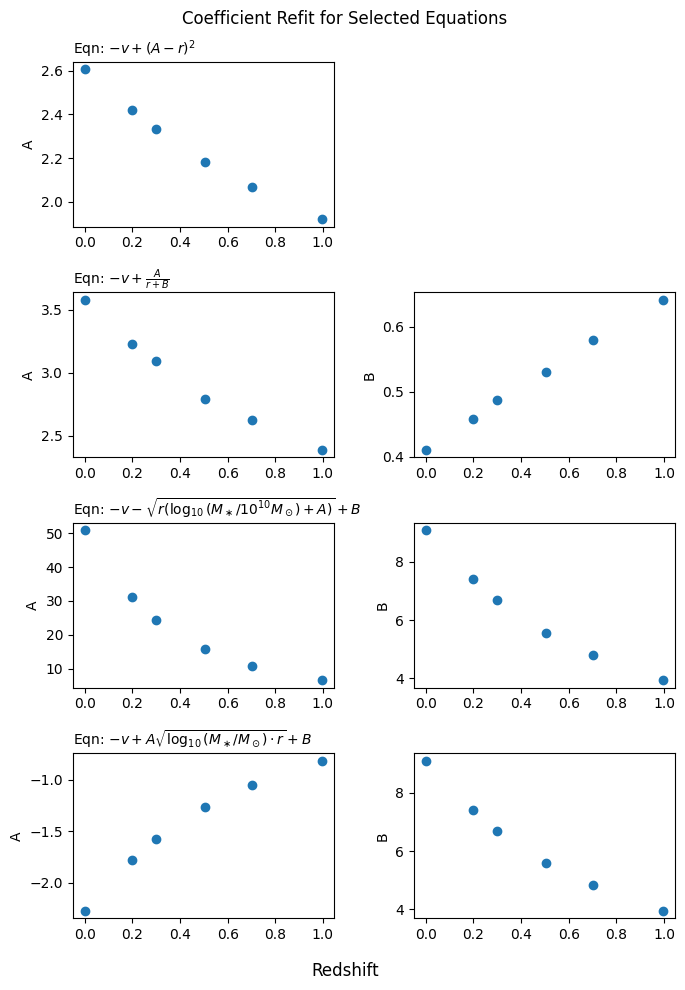

In [26]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(7, 10))
axes = axes.flatten()

axes[0].scatter(redshifts, co1s1)
axes[0].set_title(r"Eqn: $-v + (A - r)^2$", loc='left', fontsize='10')
axes[0].set_ylabel('A')
axes[1].set_axis_off()

axes[2].scatter(redshifts, co1s2)
axes[2].set_title(r"Eqn: $-v + \frac{A}{r + B}$", loc='left', fontsize='10')
axes[2].set_ylabel('A')
axes[3].scatter(redshifts, co2s2)
axes[3].set_ylabel('B')

axes[4].scatter(redshifts, co1s3)
axes[4].set_title(r"Eqn: $-v - \sqrt{r(\log_{10}(M_\ast/10^{10} M_\odot) + A)} + B$", loc='left', fontsize='10')
axes[4].set_ylabel('A')
axes[5].scatter(redshifts, co2s3)
axes[5].set_ylabel('B')

axes[6].scatter(redshifts, co1s3_2)
axes[6].set_title(r"Eqn: $-v + A\sqrt{\log_{10}(M_\ast/M_\odot) \cdot r} + B$", loc='left', fontsize='10')
axes[6].set_ylabel('A')
axes[7].scatter(redshifts, co2s3_2)
axes[7].set_ylabel('B')

fig.supxlabel("Redshift")
fig.suptitle("Coefficient Refit for Selected Equations")
    
plt.tight_layout()
plt.show()

Quadratic fit on Coefficients

In [48]:
def quadFit(redshift, A, B, C):
    z=redshift
    return A*z**2 + B*z + C
def lineFit(redshift, A, B):
    z=redshift
    return A*z + B

In [49]:
# curve fit for each equation
p0 = [1.0,1.0,1.0]
popta1, pcova1 = curve_fit(quadFit, redshifts, co1s1, p0 = p0, nan_policy='omit')
print(popta1)

p0 = [1.0,1.0,1.0]
popta2, pcova2 = curve_fit(quadFit, redshifts, co1s2, p0 = p0, nan_policy='omit')
print(popta2)
p0 = [1.0,1.0]
poptb2, pcovb2 = curve_fit(lineFit, redshifts, co2s2, p0 = p0, nan_policy='omit')
print(poptb2)

p0 = [1.0,1.0,1.0]
popta3, pcova3 = curve_fit(quadFit, redshifts, co1s3, p0 = p0, nan_policy='omit')
print(popta3)
p0 = [1.0,1.0,1.0]
poptb3, pcovb3 = curve_fit(quadFit, redshifts, co2s3, p0 = p0, nan_policy='omit')
print(poptb3)

p0 = [1.0,1.0,1.0]
popta3_2, pcova3_2 = curve_fit(quadFit, redshifts, co1s3_2, p0 = p0, nan_policy='omit')
print(popta3_2)
p0 = [1.0,1.0,1.0]
poptb3_2, pcovb3_2 = curve_fit(quadFit, redshifts, co2s3_2, p0 = p0, nan_policy='omit')
print(poptb3_2)

p0 = [1.0,1.0,1.0]
popta78, pcova78 = curve_fit(quadFit, redshifts, co1s78, p0 = p0, nan_policy='omit')
print(popta78)
p0 = [1.0,1.0,1.0]
poptb78, pcovb78 = curve_fit(quadFit, redshifts, co2s78, p0 = p0, nan_policy='omit')
print(poptb78)
p0 = [1.0,1.0,1.0]
poptc78, pcovc78 = curve_fit(quadFit, redshifts, co3s78, p0 = p0, nan_policy='omit')
print(poptb78)

[ 0.31132497 -0.99350291  2.60421121]
[ 0.67140485 -1.85169108  3.57428763]
[0.23148238 0.41374419]
[ 52.99369464 -94.85154243  49.40367062]
[ 3.6983114  -8.75234119  9.02833332]
[-1.10924862  2.53332788 -2.25535274]
[ 3.68377605 -8.73702037  9.04224228]
[-0.70259911  1.4616388  -1.01014768]
[ 0.11207237 -0.33739999  0.49618453]
[ 0.11207237 -0.33739999  0.49618453]


In [50]:
# print eqns for a, b, c depending on z

print("Eqn 1:")
print(f"{popta1[0]:.4f}*z**2 + {popta1[1]:.4f}*z + {popta1[2]:.4f}")

print("Eqn 2:")
print(f"{popta2[0]:.4f}*z**2 + {popta2[1]:.4f}*z + {popta2[2]:.4f}")
print(f"{poptb2[0]:.4f}*z + {poptb2[1]:.4f}")

print("Eqn 3:")
print(f"{popta3[0]:.4f}*z**2 + {popta3[1]:.4f}*z + {popta3[2]:.4f}")
print(f"{poptb3[0]:.4f}*z**2 + {poptb3[1]:.4f}*z + {poptb3[2]:.4f}")

print("Eqn 3_2:")
print(f"{popta3_2[0]:.4f}*z**2 + {popta3_2[1]:.4f}*z + {popta3_2[2]:.4f}")
print(f"{poptb3_2[0]:.4f}*z**2 + {poptb3_2[1]:.4f}*z + {poptb3_2[2]:.4f}")

print("Eqn test78:")
print(f"{popta78[0]:.4f}*z**2 + {popta78[1]:.4f}*z + {popta78[2]:.4f}")
print(f"{poptb78[0]:.4f}*z**2 + {poptb78[1]:.4f}*z + {poptb78[2]:.4f}")
print(f"{poptc78[0]:.4f}*z**2 + {poptc78[1]:.4f}*z + {poptc78[2]:.4f}")

Eqn 1:
0.3113*z**2 + -0.9935*z + 2.6042
Eqn 2:
0.6714*z**2 + -1.8517*z + 3.5743
0.2315*z + 0.4137
Eqn 3:
52.9937*z**2 + -94.8515*z + 49.4037
3.6983*z**2 + -8.7523*z + 9.0283
Eqn 3_2:
-1.1092*z**2 + 2.5333*z + -2.2554
3.6838*z**2 + -8.7370*z + 9.0422
Eqn test78:
-0.7026*z**2 + 1.4616*z + -1.0101
0.1121*z**2 + -0.3374*z + 0.4962
-0.6824*z**2 + 1.9914*z + -3.1072


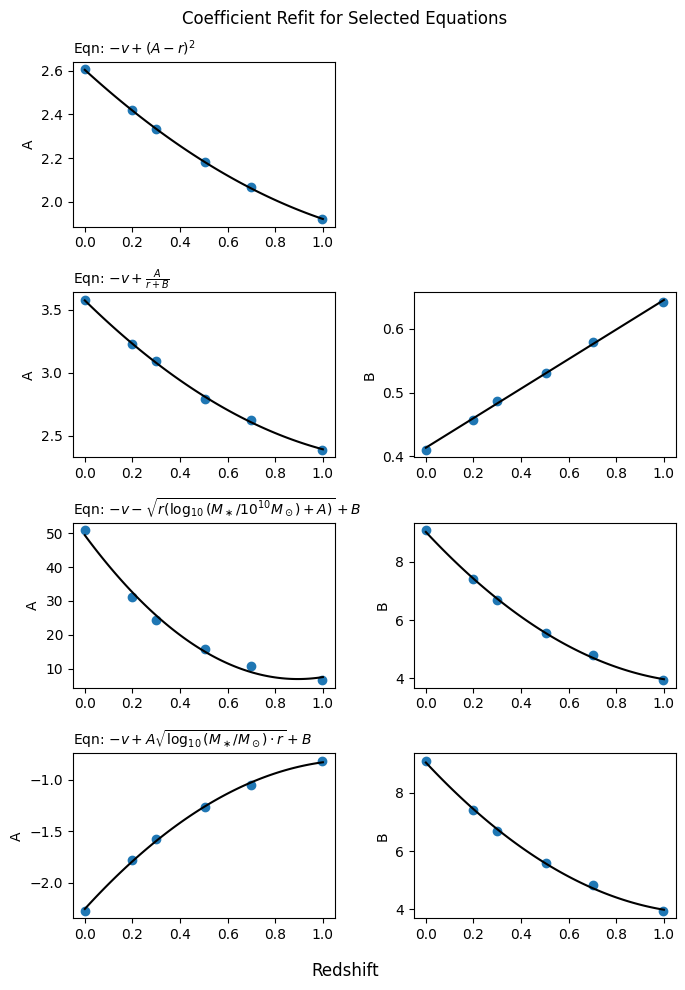

In [51]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(7, 10))
axes = axes.flatten()

axes[0].scatter(redshifts, co1s1)
axes[0].set_title(r"Eqn: $-v + (A - r)^2$", loc='left', fontsize='10')
axes[0].set_ylabel('A')
z_in = np.linspace(0,1.0,100)
eqn = popta1[0]*z_in**2 + popta1[1]*z_in + popta1[2]
axes[0].plot(z_in,eqn, color='black')
axes[1].set_axis_off()

axes[2].scatter(redshifts, co1s2)
axes[2].set_title(r"Eqn: $-v + \frac{A}{r + B}$", loc='left', fontsize='10')
axes[2].set_ylabel('A')
z_in = np.linspace(0,1.0,100)
eqn = popta2[0]*z_in**2 + popta2[1]*z_in + popta2[2]
axes[2].plot(z_in,eqn, color='black')
axes[3].scatter(redshifts, co2s2)
axes[3].set_ylabel('B')
z_in = np.linspace(0,1.0,100)
eqn = poptb2[0]*z_in + poptb2[1]
axes[3].plot(z_in,eqn, color='black')

axes[4].scatter(redshifts, co1s3)
axes[4].set_title(r"Eqn: $-v - \sqrt{r(\log_{10}(M_\ast/10^{10} M_\odot) + A)} + B$", loc='left', fontsize='10')
axes[4].set_ylabel('A')
z_in = np.linspace(0,1.0,100)
eqn = popta3[0]*z_in**2 + popta3[1]*z_in + popta3[2]
axes[4].plot(z_in,eqn, color='black')
axes[5].scatter(redshifts, co2s3)
axes[5].set_ylabel('B')
z_in = np.linspace(0,1.0,100)
eqn = poptb3[0]*z_in**2 + poptb3[1]*z_in + poptb3[2]
axes[5].plot(z_in,eqn, color='black')

axes[6].scatter(redshifts, co1s3_2)
axes[6].set_title(r"Eqn: $-v + A\sqrt{\log_{10}(M_\ast/M_\odot) \cdot r} + B$", loc='left', fontsize='10')
axes[6].set_ylabel('A')
z_in = np.linspace(0,1.0,100)
eqn = popta3_2[0]*z_in**2 + popta3_2[1]*z_in + popta3_2[2]
axes[6].plot(z_in,eqn, color='black')
axes[7].scatter(redshifts, co2s3_2)
axes[7].set_ylabel('B')
z_in = np.linspace(0,1.0,100)
eqn = poptb3_2[0]*z_in**2 + poptb3_2[1]*z_in + poptb3_2[2]
axes[7].plot(z_in,eqn, color='black')

fig.supxlabel("Redshift")
fig.suptitle("Coefficient Refit for Selected Equations")
    
plt.tight_layout()
plt.show()

Text(0, 0.5, 'C')

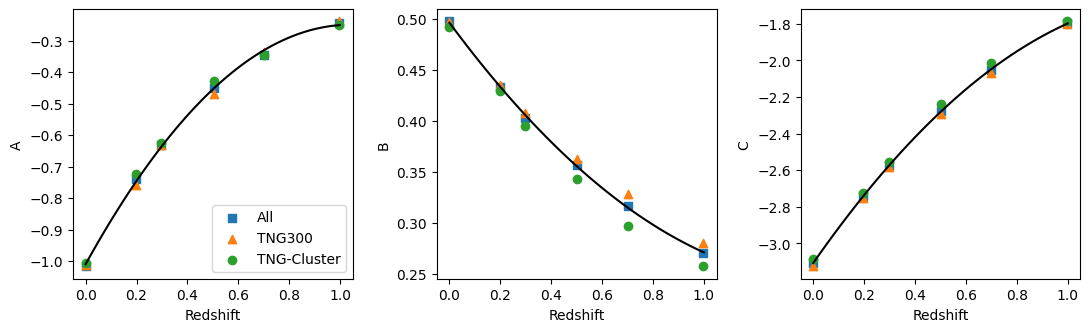

In [54]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 3.5))
plt.subplots_adjust(wspace=0.3)
axes = axes.flatten()

axes[0].scatter(redshifts, co1s78, marker='s', label='All')
axes[0].scatter(redshifts, co1s78_300, marker='^', label='TNG300')
axes[0].scatter(redshifts, co1s78_Cluster, marker='o', label='TNG-Cluster')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('A')
z_in = np.linspace(0,1.0,100)
eqn = popta78[0]*z_in**2 + popta78[1]*z_in + popta78[2]
axes[0].legend(loc='lower right')
axes[0].plot(z_in,eqn, color='black')
axes[1].scatter(redshifts, co2s78, marker='s')
axes[1].scatter(redshifts, co2s78_300, marker='^')
axes[1].scatter(redshifts, co2s78_Cluster, marker='o')
z_in = np.linspace(0,1.0,100)
eqn = poptb78[0]*z_in**2 + poptb78[1]*z_in + poptb78[2]
axes[1].plot(z_in,eqn, color='black')
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('B')
axes[2].scatter(redshifts, co3s78, marker='s')
axes[2].scatter(redshifts, co3s78_300, marker='^')
axes[2].scatter(redshifts, co3s78_Cluster, marker='o')
z_in = np.linspace(0,1.0,100)
eqn = poptc78[0]*z_in**2 + poptc78[1]*z_in + poptc78[2]
axes[2].plot(z_in,eqn, color='black')
axes[2].set_xlabel('Redshift')
axes[2].set_ylabel('C')


Comparison of Equations Across Redshift Median Galaxy

In [55]:
def eqn1noMPlot(Xvect, z): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = popta1[0]*z**2 + popta1[1]*z + popta1[2]

    return np.maximum(0,-v + (a - r)**2)

def eqn2noMPlot(Xvect, z): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = popta2[0]*z**2 + popta2[1]*z + popta2[2]
    b = poptb2[0]*z + poptb2[1]

    return np.maximum(0,-v + a/(r + b))

def eqn3Plot(Xvect, z): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = popta3[0]*z**2 + popta3[1]*z + popta3[2]
    b = poptb3[0]*z**2 + poptb3[1]*z + poptb3[2]

    return np.maximum(0,-v - np.sqrt(r*((logms-10) + a)) + b)

def eqn3_2Plot(Xvect, z): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = popta3_2[0]*z**2 + popta3_2[1]*z + popta3_2[2]
    b = poptb3_2[0]*z**2 + poptb3_2[1]*z + poptb3_2[2]

    return np.maximum(0,-v + a*np.sqrt(logms*r) + b)

def testz78Plot(Xvect, z):
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = popta78[0]*z**2 + popta78[1]*z + popta78[2]
    b = poptb78[0]*z**2 + poptb78[1]*z + poptb78[2]
    c = poptc78[0]*z**2 + poptc78[1]*z + poptc78[2]
    return np.maximum(0, a*v + (b*np.sqrt(logms*r) + c)**2)
    # return np.maximum(0, (a*v**2 + b*np.sqrt(logms*r) + c)**2)


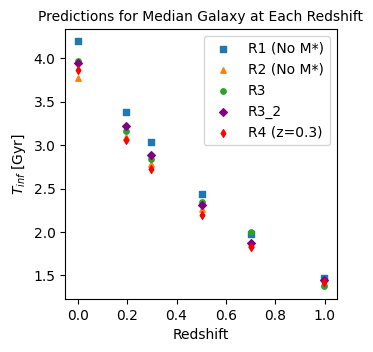

In [56]:
plt.figure(figsize=(3.5,3.5))

plot_redshifts = []
estimates1 = []
estimates2 = []
estimates3 = []
estimates3_2 = []
estimates4 = []

for i, snapshot in enumerate(snapshots):
    medianr = np.median(r_axis_clean[snapshot])
    medianv = np.median(v_axis_clean[snapshot])
    medianm = np.median(m_axis_clean[snapshot])
    Xvect = [medianr, medianv, medianm]

    predicted_T_1 = eqn1noMPlot(Xvect, redshifts[i])
    predicted_T_2 = eqn2noMPlot(Xvect, redshifts[i])
    predicted_T_3 = eqn3Plot(Xvect, redshifts[i])
    predicted_T_3_2 = eqn3_2Plot(Xvect, redshifts[i])
    predicted_T_4 = testz78Plot(Xvect, redshifts[i])
    plot_redshifts.append(redshifts[i])
    estimates1.append(predicted_T_1)
    estimates2.append(predicted_T_2)
    estimates3.append(predicted_T_3)
    estimates3_2.append(predicted_T_3_2)
    estimates4.append(predicted_T_4)

plt.scatter(redshifts, estimates1, marker='s', label='R1 (No M*)', s=15)
plt.scatter(redshifts, estimates2, marker='^', label='R2 (No M*)', s=15)
plt.scatter(redshifts, estimates3, marker='o', label='R3', s=15)
plt.scatter(redshifts, estimates3_2, marker='D', label='R3_2', s=15, color='purple')
plt.scatter(redshifts, estimates4, marker='d', label='R4 (z=0.3)', s=15, color='red')
plt.xlabel('Redshift')
plt.ylabel(r'$T_{inf}$ [Gyr]')
plt.title("Predictions for Median Galaxy at Each Redshift", fontsize='10')
plt.legend()

RMSEs of Each Equation

In [57]:
rmse4 = []
for i, snapshot in enumerate(snapshots):
    redshift = redshifts[i]
    r_raw = r_axis_clean[snapshot]
    v_raw = np.abs(v_axis_clean[snapshot])
    m_raw = m_axis_clean[snapshot]
    y_raw = infall_axis1_clean[snapshot]
    
    X_raw = np.column_stack((r_raw, v_raw, m_raw))

    clean_rows = ~np.isnan(X_raw).any(axis=1) & ~np.isnan(y_raw)
    
    X_clean = X_raw[clean_rows]
    y_clean = y_raw[clean_rows]
    
    pred1 = eqn1noMPlot(X_clean.T, redshift)
    pred2 = eqn2noMPlot(X_clean.T, redshift)
    pred3 = eqn3Plot(X_clean.T, redshift)
    pred3_2 = eqn3_2Plot(X_clean.T, redshift)
    pred4 = testz78Plot(X_clean.T, redshift)

    rmse1 = np.sqrt(mean_squared_error(y_clean, pred1))
    rmse2 = np.sqrt(mean_squared_error(y_clean, pred2))
    rmse3 = np.sqrt(mean_squared_error(y_clean, pred3))
    rmse3_2 = np.sqrt(mean_squared_error(y_clean, pred3_2))
    rmse4.append(np.sqrt(mean_squared_error(y_clean, pred4)))

    print(f"RMSEs at redshift: {round(redshift,2)} | Mean infall time at this redshift: {np.mean((y_clean))}")
    print(f"    Eqn1: {round(rmse1,2)}\n    Eqn2: {round(rmse2,2)}\n    Eqn3: {round(rmse3,2)}\n    Eqn3_2: {round(rmse3_2,2)}\n    Eqn4: {round(rmse4[i],2)}")


RMSEs at redshift: 0.0 | Mean infall time at this redshift: 3.9046003853928077
    Eqn1: 2.68
    Eqn2: 2.62
    Eqn3: 2.61
    Eqn3_2: 2.61
    Eqn4: 2.61
RMSEs at redshift: 0.2 | Mean infall time at this redshift: 3.1142913742324234
    Eqn1: 2.09
    Eqn2: 2.06
    Eqn3: 2.05
    Eqn3_2: 2.05
    Eqn4: 2.04
RMSEs at redshift: 0.3 | Mean infall time at this redshift: 2.7796501982433095
    Eqn1: 1.87
    Eqn2: 1.85
    Eqn3: 1.84
    Eqn3_2: 1.84
    Eqn4: 1.82
RMSEs at redshift: 0.5 | Mean infall time at this redshift: 2.223347312248539
    Eqn1: 1.56
    Eqn2: 1.55
    Eqn3: 1.54
    Eqn3_2: 1.54
    Eqn4: 1.48
RMSEs at redshift: 0.7 | Mean infall time at this redshift: 1.8557969105284098
    Eqn1: 1.34
    Eqn2: 1.34
    Eqn3: 1.34
    Eqn3_2: 1.33
    Eqn4: 1.23
RMSEs at redshift: 1.0 | Mean infall time at this redshift: 1.4648316945440285
    Eqn1: 1.12
    Eqn2: 1.11
    Eqn3: 1.11
    Eqn3_2: 1.11
    Eqn4: 0.94


Comparison of Predicted vs Actual at Different Redshifts

Text(0.07, 0.5, 'Predicted $T_{inf,grid}$ [Gyr]')

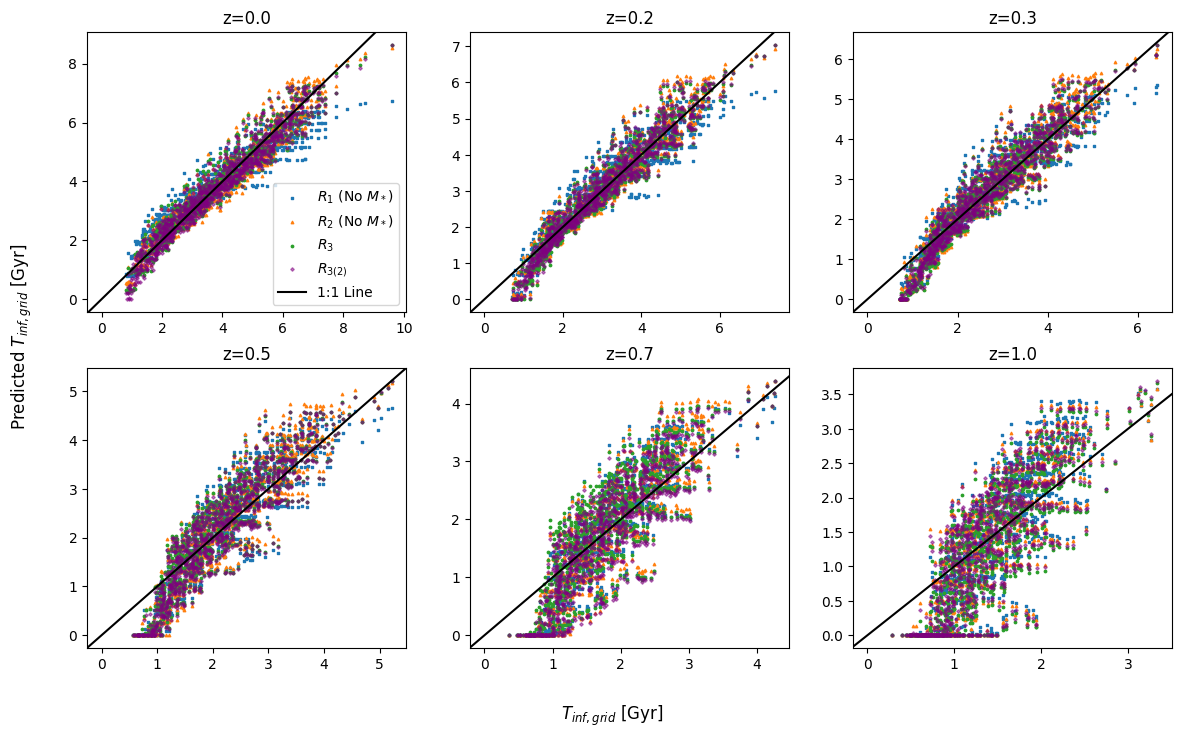

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
plt.subplots_adjust(hspace=0.2, wspace=0.2)
ax = axes.flatten()

for i in range(6):
    snapshot = snapshots[i]
    ax[i].scatter(y_mean[snapshot], eqn1noMPlot(X_binned[snapshot].T, redshifts[i]), label=r'$R_1$ (No $M_*$)', marker='s', s=3)
    ax[i].scatter(y_mean[snapshot], eqn2noMPlot(X_binned[snapshot].T, redshifts[i]), label=r'$R_2$ (No $M_*$)', marker='^', s=3)
    ax[i].scatter(y_mean[snapshot], eqn3Plot(X_binned[snapshot].T, redshifts[i]), label=r'$R_3$', marker='o', s=3)
    ax[i].scatter(y_mean[snapshot], eqn3_2Plot(X_binned[snapshot].T, redshifts[i]), label=r'$R_{3 (2)}$', marker='D', s=3, color='purple', alpha=0.5)
    # ax[i].scatter(y_mean[snapshot], testz78Plot(X_binned[snapshot].T, redshifts[i]), label='R4 (z=0.3)', marker='D', s=3, color='red', alpha=0.5)
    ax[i].axline((0, 0), slope=1, color='black', label='1:1 Line')
    ax[i].set_title(f"z={round(redshifts[i],2)}")

ax[0].legend()

fig.supxlabel(r"$T_{inf,grid}$ [Gyr]")
fig.supylabel(r"Predicted $T_{inf,grid}$ [Gyr]", x=0.07)
# fig.suptitle(r"Predicted vs True Infall Time Across Redshift")
# fig.suptitle(r"Predicted vs True Infall Time for $T_{inf}=Av + \left(B\sqrt{r\cdot\log_{10}(M_{\ast}/M_{\odot})} - C\right)^2$", linespacing=1.5)


# plt.tight_layout()